# Tracking Data Analysis
Reload and analyze time_tracking data from saved CSVs

In [130]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.calib.time_tracking import load_tracking
from slab_qick_calib.analysis import collections, allan, qubit_params
from slab_qick_calib.helpers import config
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [131]:
cfg_file = 'sample_50_rfboard.yml'
expt_path = r'C:\_Data'
cfg_path = os.path.join(os.getcwd(), '..', 'configs', cfg_file)

csv_dir = os.path.join(expt_path, 'Tracking', 'csv')
qubit_list = [0]

## Load tracking data from CSVs

In [132]:
tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)

Loaded tracking_id='2026_03_22_09_19_24.0hrs', qubits=[0, 1, 2]
  CSV last updated: 2026-03-22 13:44:22 (0h 0m ago)


## Process data and add derived quantities

In [133]:
tt, tt_ave = collections.process_data(tt)
tt = collections.add_losses(tt)

In [134]:
tt_ave

{'t1_mn': array([0.39148482, 0.37354045, 1.43044422]),
 't1_std': array([0.04436655, 0.06906029, 0.23815368]),
 't1_off_mn': array([  5.93238567, -12.74410535, -55.2357665 ]),
 't1_off_std': array([0.59364733, 0.56018868, 1.80688603]),
 't1_amp_mn': array([18.33083916, 14.76777047, 22.77814337]),
 't1_amp_std': array([1.07651235, 1.73466503, 1.02638318]),
 't2_off_mn': array([ 15.73209251,   2.93624367, -42.48990593]),
 't2_off_std': array([0.43851145, 1.48570701, 2.23746115]),
 't2_amp_mn': array([ 5.47683165, 12.48259889, 14.59454854]),
 't2_amp_std': array([ 6.27169145, 10.10179119,  2.52199802]),
 't2_mn': array([0.07475615, 0.09493663, 0.33386951]),
 't2_std': array([0.01194965, 0.02240266, 0.07140836]),
 'f_ge_mn': array([5621.5280364 , 4540.72294792, 3398.04990487]),
 'f_ge_std': array([7.38890692, 3.28010332, 0.21740509]),
 't2_err_mn': array([0.01280553, 0.01224487, 0.03977805]),
 't2_err_std': array([0.00373083, 0.01113581, 0.09823216]),
 'fge_err_mn': array([0.34569482, 0.17

## Allan variance analysis

 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16RuntimeWarning: overflow encountered in exp
 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

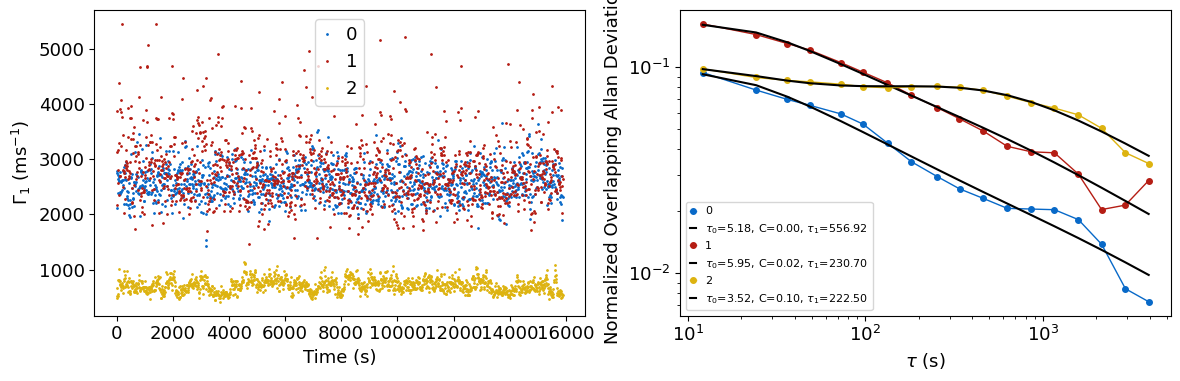

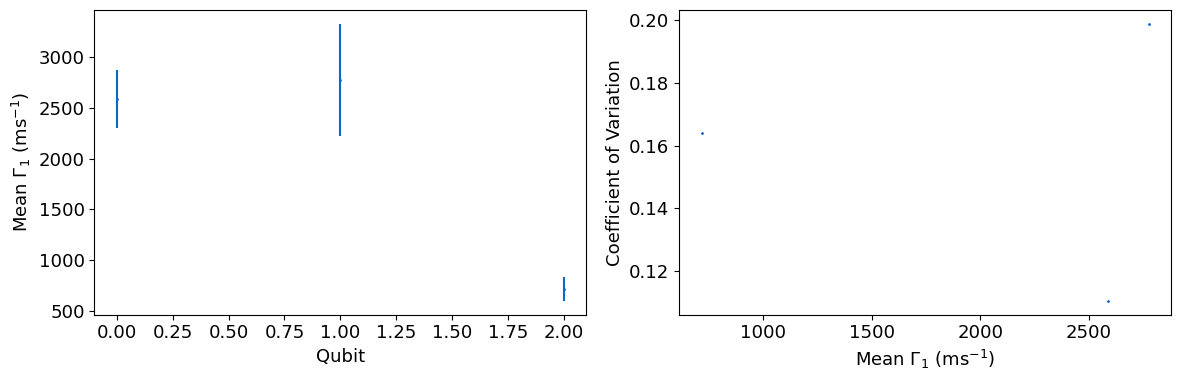

In [135]:
allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)

## Allan analysis (allantools)

Enhanced Allan deviation analysis using the `allantools` package.

### Deviation types

| Abbreviation | Name | Description |
|---|---|---|
| **ADEV** | Allan Deviation | Standard two-sample deviation. Most common stability measure. |
| **OADEV** | Overlapping Allan Deviation | Uses overlapping samples for better confidence at long tau. Same expectation as ADEV but lower variance. |
| **MDEV** | Modified Allan Deviation | Can distinguish white PM from flicker PM noise (ADEV cannot). |
| **HDEV** | Hadamard Deviation | Insensitive to linear frequency drift — useful when drift dominates. |
| **OHDEV** | Overlapping Hadamard Deviation | Overlapping version of HDEV. |
| **TDEV** | Time Deviation | Derived from MDEV; characterizes time stability rather than frequency stability. |
| **TOTDEV** | Total Deviation | Extends analysis to longer tau by reflecting data at boundaries. |

### Noise types (from log-log slope of ADEV vs tau)

| Abbreviation | Name | ADEV slope | Physical origin (qubit context) |
|---|---|---|---|
| **WPM** | White Phase Modulation | -1 | Measurement noise, digitization |
| **FPM** | Flicker Phase Modulation | -1 (same as WPM for ADEV) | Low-frequency measurement artifacts |
| **WFM** | White Frequency Modulation | -1/2 | Uncorrelated shot-to-shot fluctuations (e.g. photon shot noise, thermal noise) |
| **FFM** | Flicker Frequency Modulation | 0 (flat) | 1/f noise — TLS defects, charge noise, flux noise |
| **RWFM** | Random Walk Frequency Modulation | +1/2 | Diffusive drift — slow temperature or field drifts |

A slope that flattens or rises at long tau typically indicates correlated (1/f) or drifting noise, while a -1/2 slope indicates white (uncorrelated) fluctuations.


Gamma1
Qubit 0: lorentz_two fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

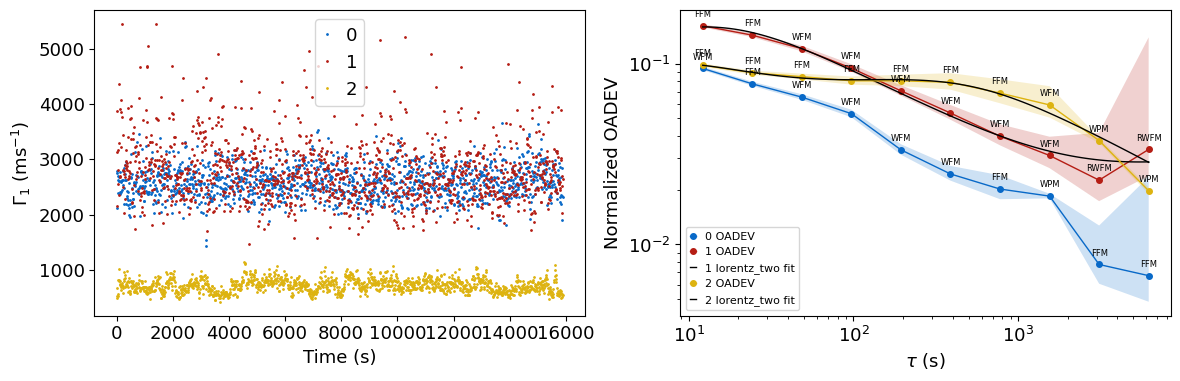

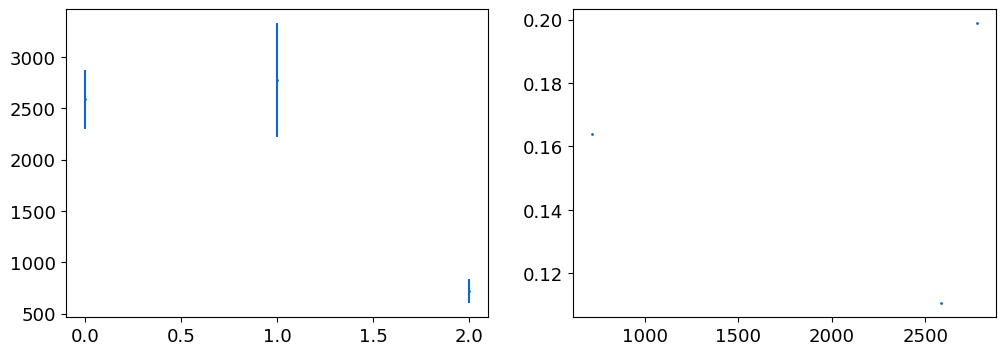


t1
Qubit 0: lorentz_two fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


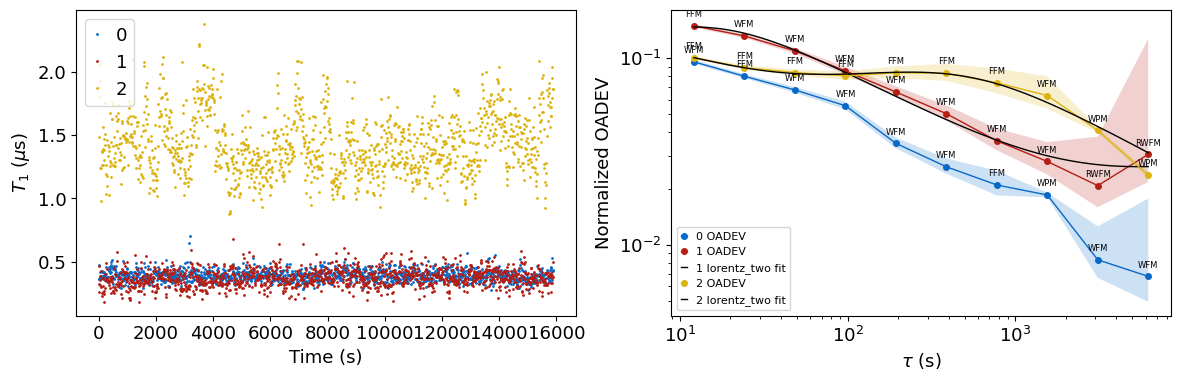

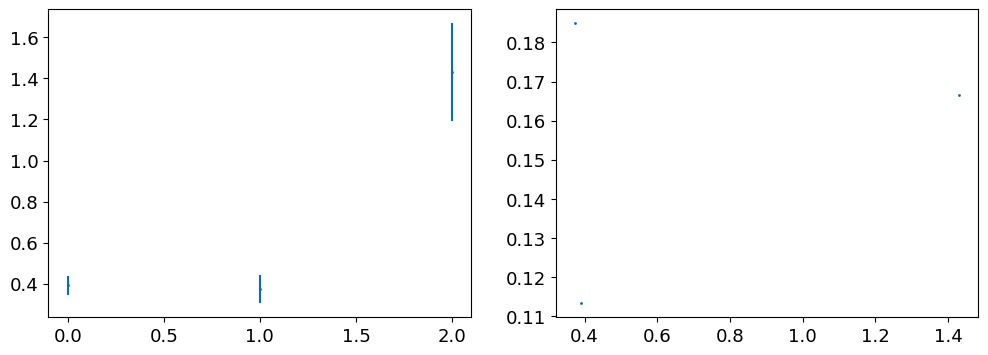


f_ge
Qubit 0: lorentz_two fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.
Qubit 2: lorentz_two fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


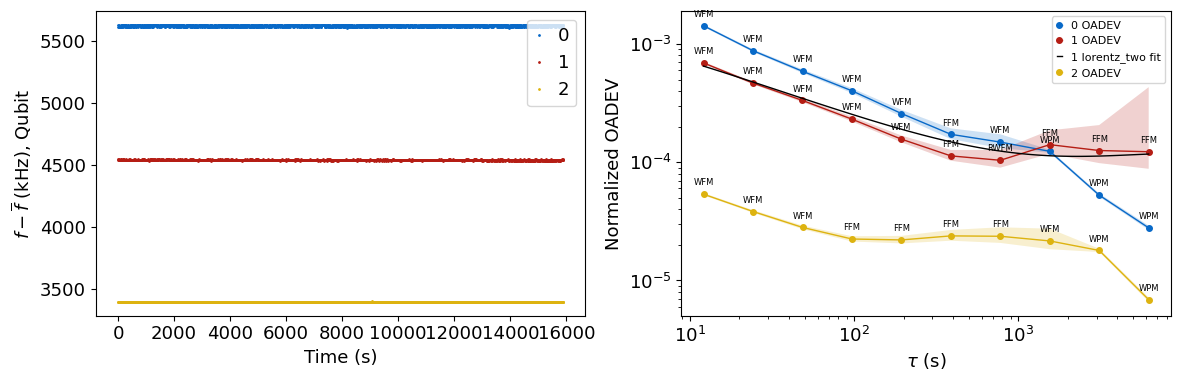

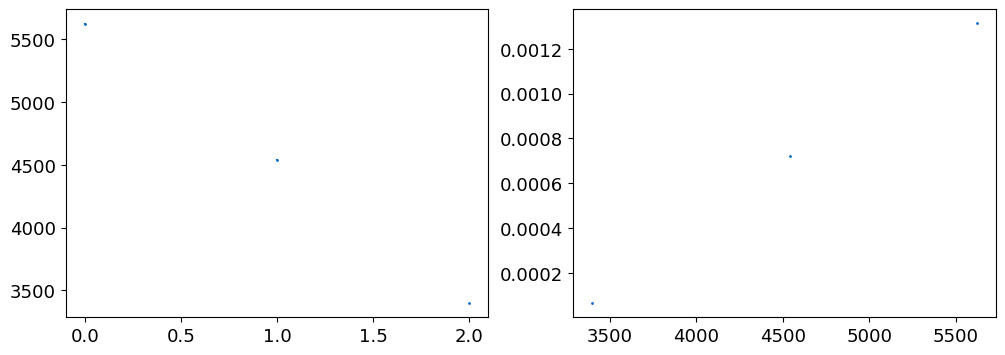

In [136]:
from slab_qick_calib.analysis.allan_at import perform_analysis_at, plot_deviation_comparison

# Full analysis per parameter with OADEV + fit
for param in ['Gamma1', 't1', 'f_ge']:
    print(f"\n{'='*60}\n{param}\n{'='*60}")
    perform_analysis_at(
        tt, param=param,
        dev_types=('oadev',), taus='octave',
        fit_models=('lorentz_two',),
        show_ci=True, show_noise_id=True,
    )

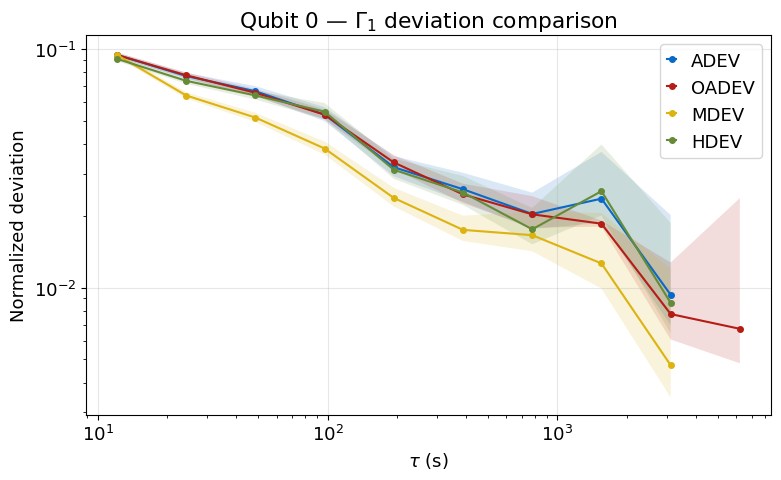

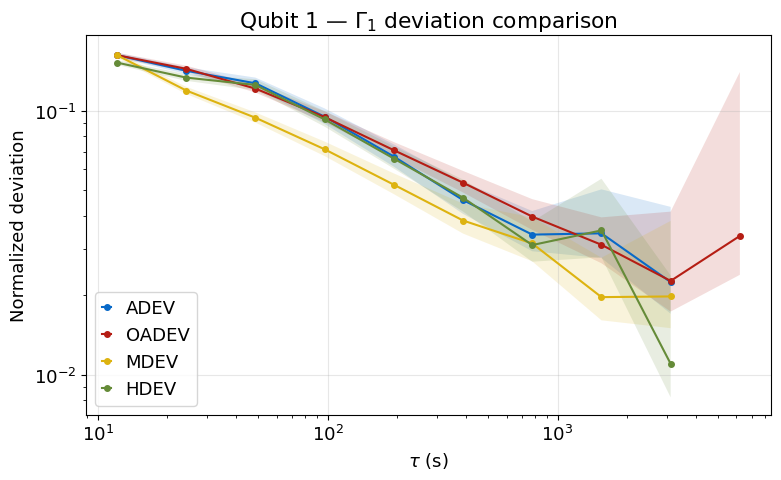

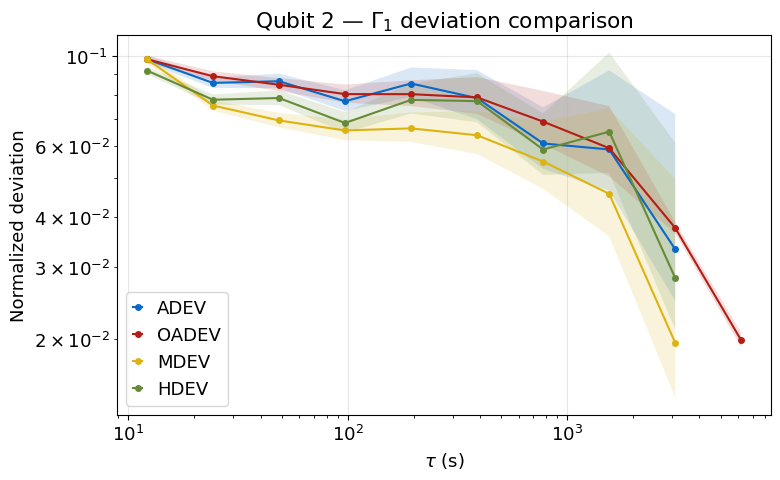

In [137]:
# Compare deviation types (ADEV, OADEV, MDEV, HDEV) for Gamma1
for qi in range(len(tt)):
    data = np.array(tt[qi]['Gamma1'])
    times = np.array(tt[qi]['time'])
    rate = 1.0 / np.mean(np.diff(times))
    plot_deviation_comparison(
        data, rate=rate,
        dev_types=('adev', 'oadev', 'mdev', 'hdev'),
        taus='octave', show_ci=True,
        title=f'Qubit {qi} — $\\Gamma_1$ deviation comparison',
    )
    plt.show()

## Time series and histograms

Number of bad inds for t1 is 3
Number of bad inds for t2 is 84
Number of bad inds for tphi is 85
Number of bad inds for f_ge is 80
Number of bad inds for t1 is 1
Number of bad inds for t2 is 121
Number of bad inds for tphi is 121
Number of bad inds for f_ge is 121
Number of bad inds for t1 is 0
Number of bad inds for t2 is 9
Number of bad inds for tphi is 9
Number of bad inds for f_ge is 2


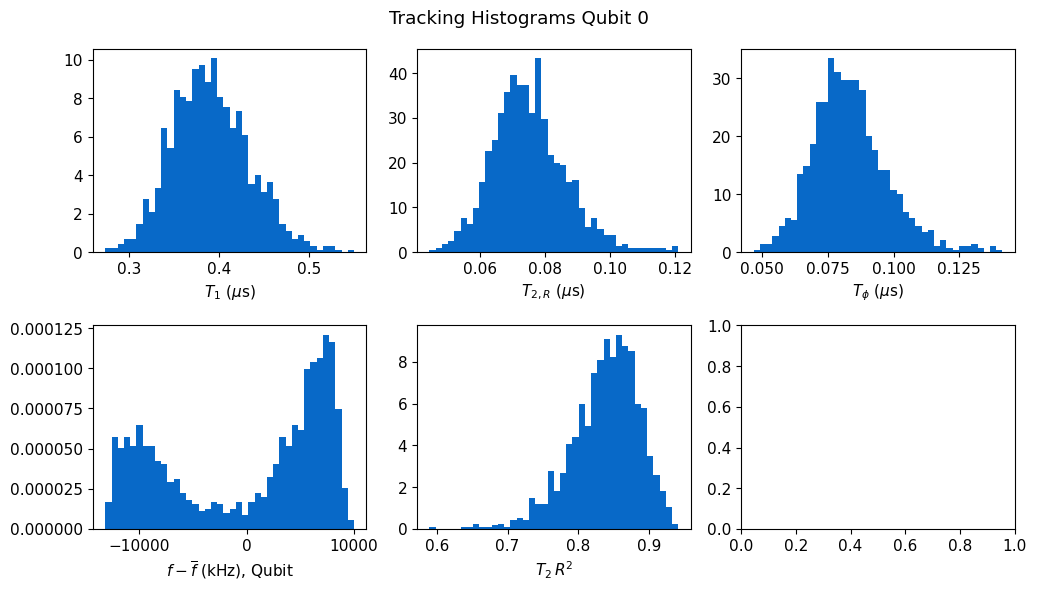

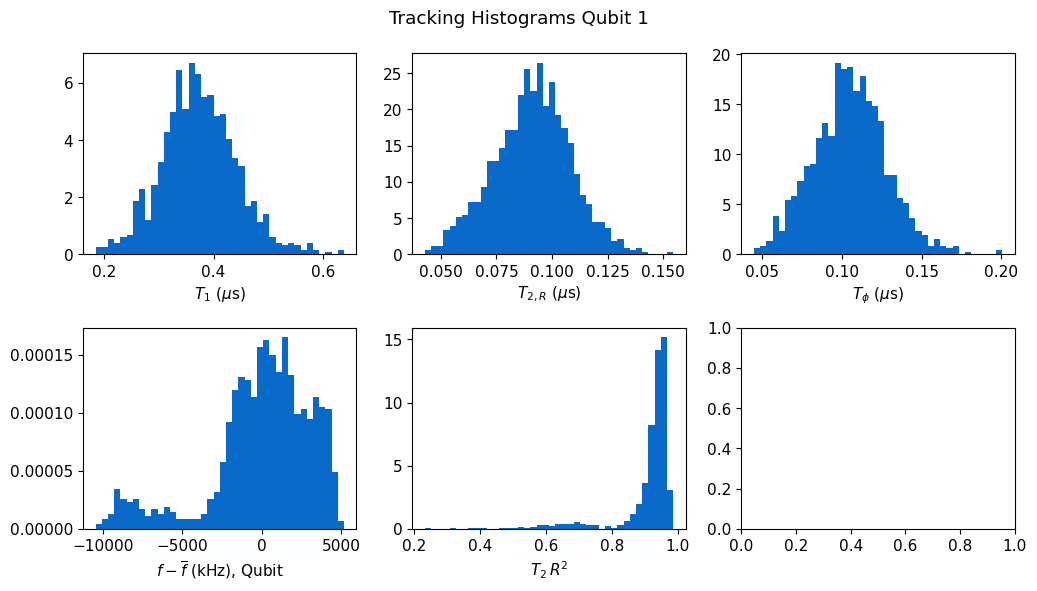

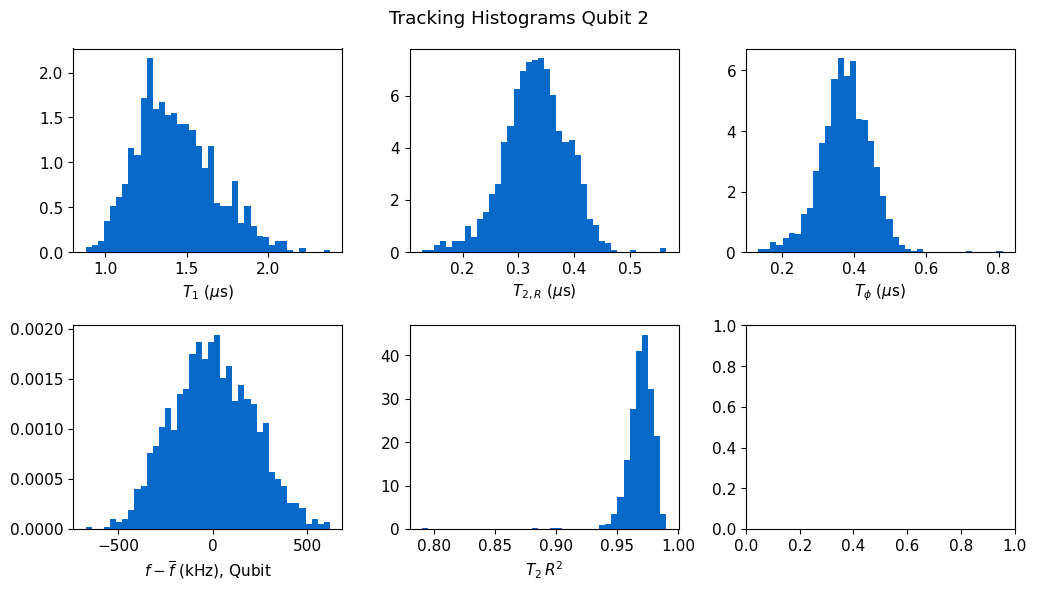

In [138]:
collections.plot_all(tt, param_keys=['t1', 't2', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
plt.show()

Number of bad inds for Gamma1 is 1
Number of bad inds for Gamma2 is 81
Number of bad inds for Gammaphi is 81
Number of bad inds for f_ge is 80
Number of bad inds for Gamma1 is 5
Number of bad inds for Gamma2 is 123
Number of bad inds for Gammaphi is 125
Number of bad inds for f_ge is 121
Number of bad inds for Gamma1 is 0
Number of bad inds for Gamma2 is 14
Number of bad inds for Gammaphi is 15
Number of bad inds for f_ge is 2


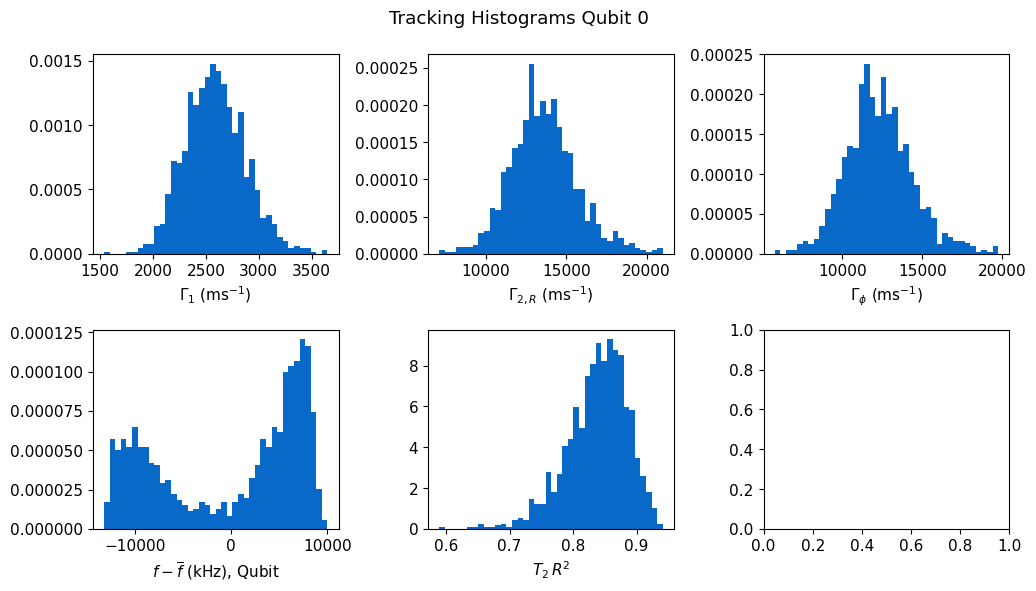

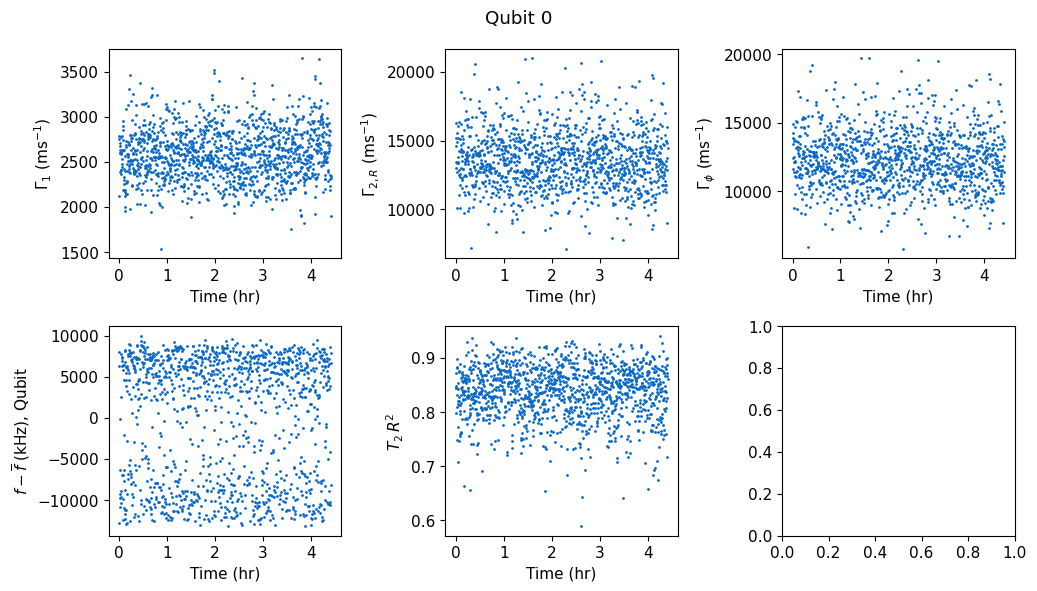

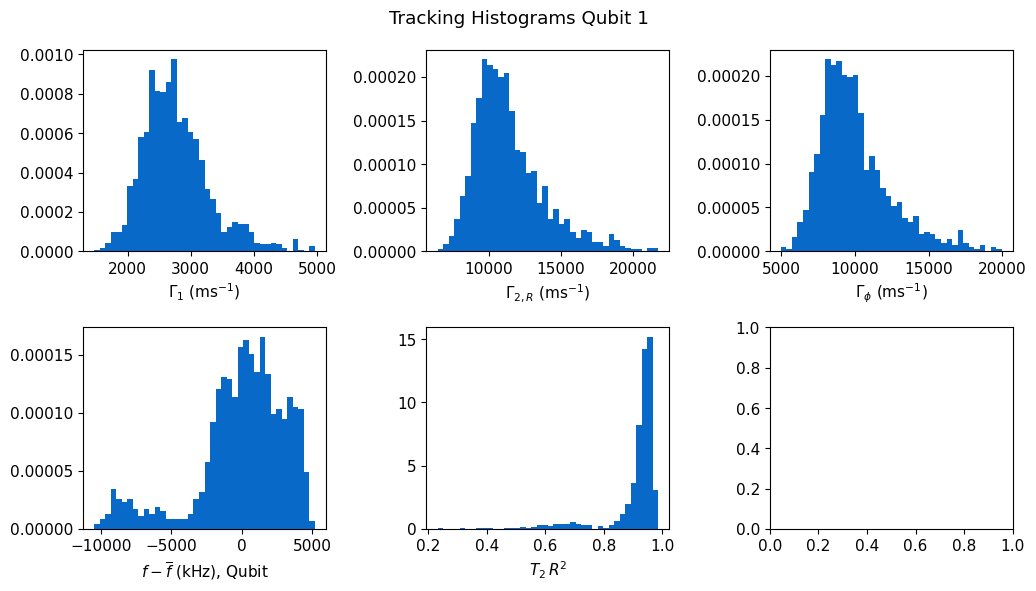

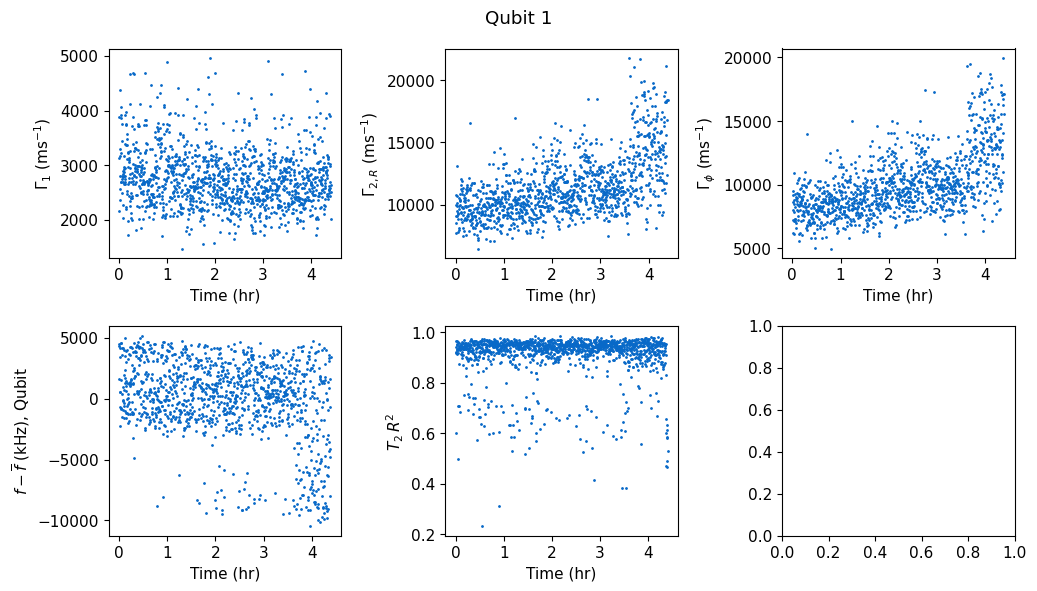

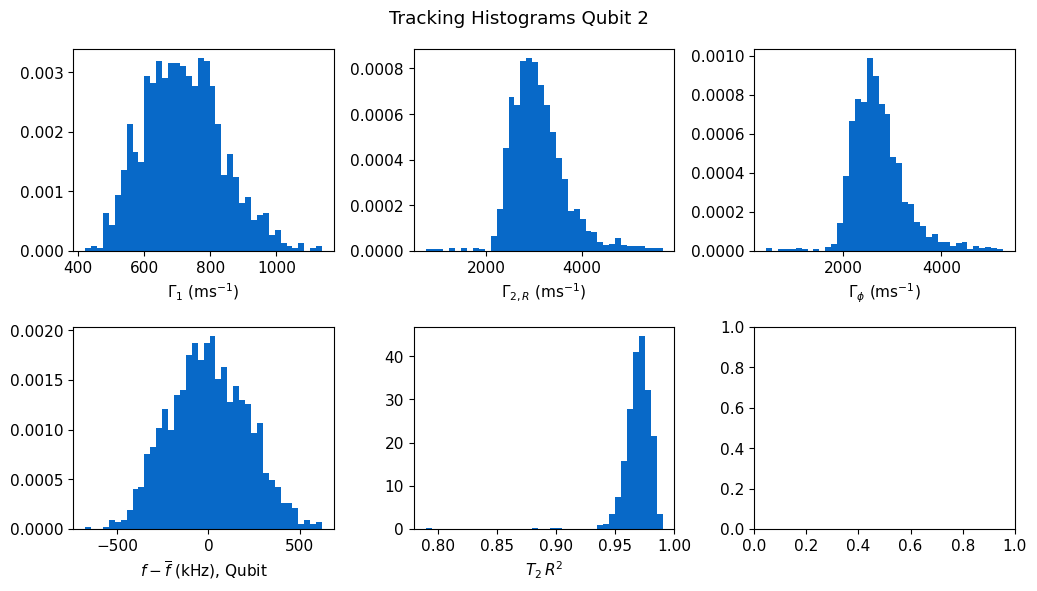

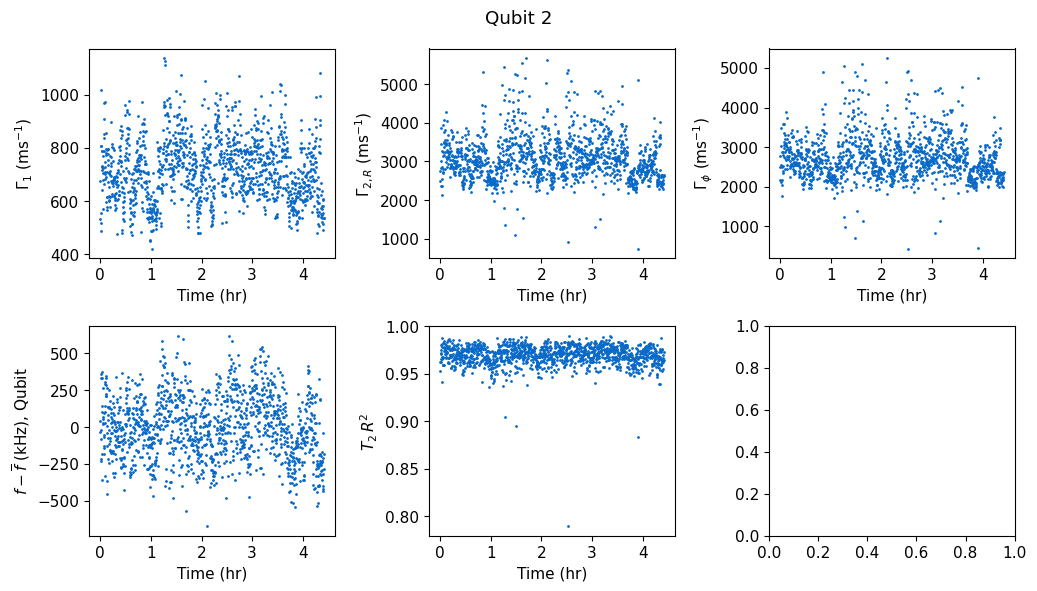

In [139]:
collections.plot_all(tt, param_keys=['Gamma1', 'Gamma2', 'Gammaphi', 'f_ge','t2_r2'], plot_time=True, save_path=csv_pth, tracking_id=tracking_id)
plt.show()

## Violin plots

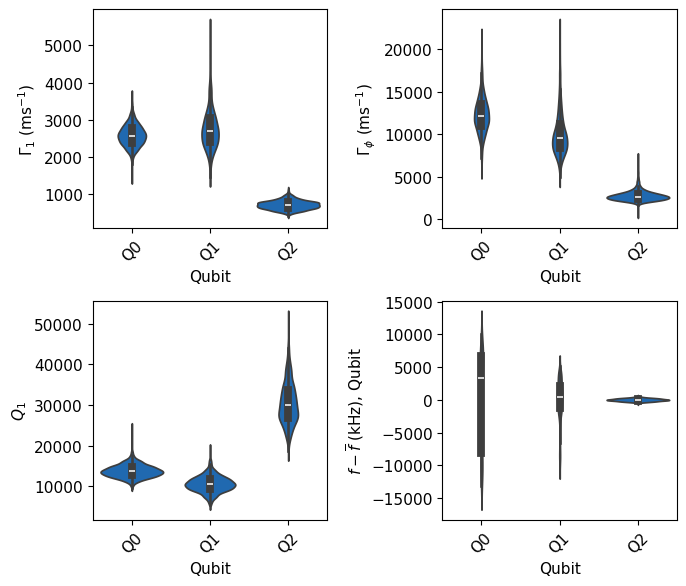

In [140]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], csv_path=csv_pth)
plt.show()

## Power Spectral Density Analysis

Median time between measurements: 12.1 s
Sampling frequency: 0.0826 Hz

Analyzing Gamma1...


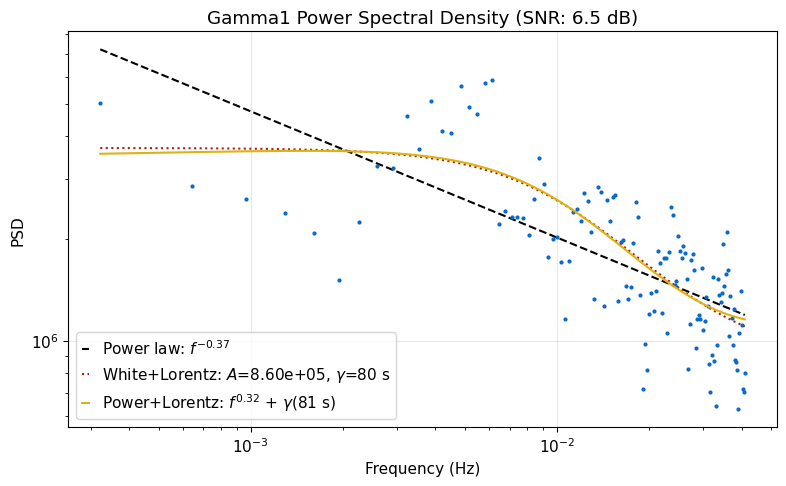

Peak frequency: 6.1308e-03 Hz (Period: 163.1 s)
Total power: 8.0181e+04
SNR: 6.5 dB

Analyzing Gammaphi...


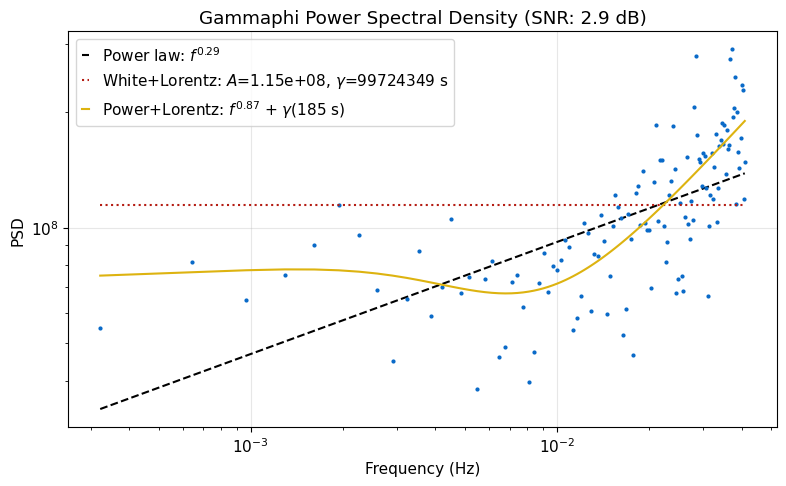

Peak frequency: 3.7108e-02 Hz (Period: 26.9 s)
Total power: 4.7282e+06
SNR: 2.9 dB

Analyzing f_ge...


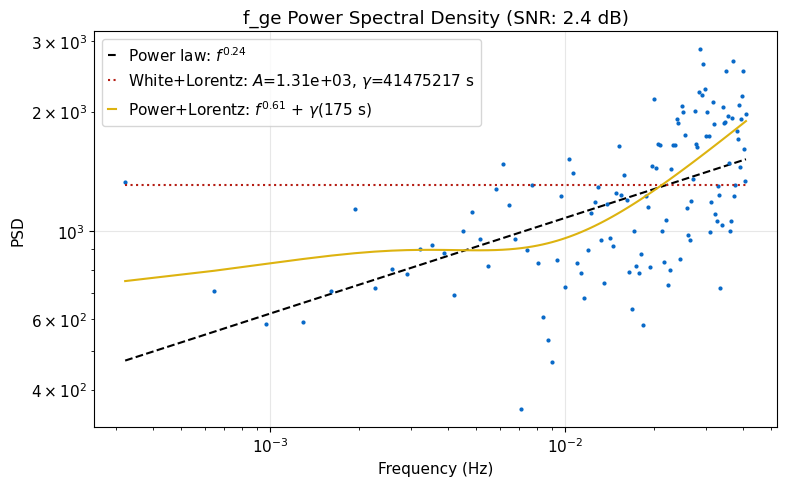

Peak frequency: 2.8718e-02 Hz (Period: 34.8 s)
Total power: 5.3746e+01
SNR: 2.4 dB

Analyzing t1...


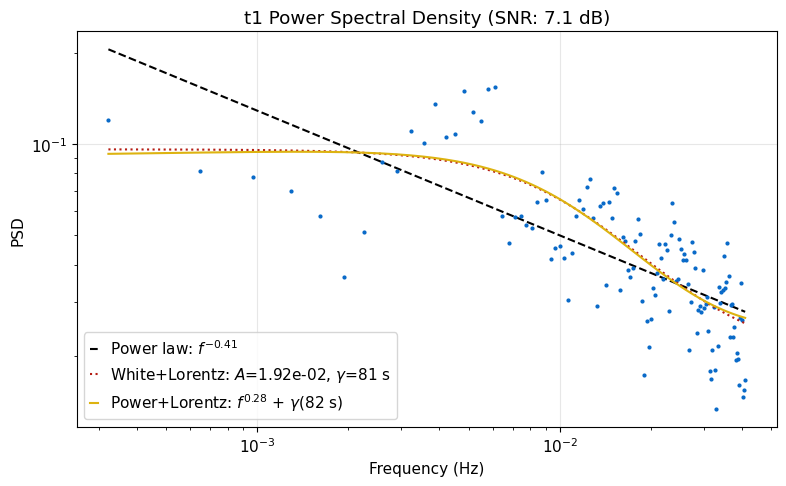

Peak frequency: 6.1308e-03 Hz (Period: 163.1 s)
Total power: 1.9920e-03
SNR: 7.1 dB


In [141]:
from slab_qick_calib.analysis.time_series import analyze_qubit_psd

# Calculate sampling frequency from timestamps
timestamps = tt[0]['time']
dt = np.median(np.diff(timestamps))  # median time between measurements (in seconds)
fs = 1 / dt  # sampling frequency in Hz

print(f"Median time between measurements: {dt:.1f} s")
print(f"Sampling frequency: {fs:.4f} Hz")

# Analyze PSD for different parameters
params_to_analyze = ['Gamma1', 'Gammaphi', 'f_ge', 't1']

for param in params_to_analyze:
    if param in tt[0]:
        data = tt[0][param]
        print(f"\n{'='*60}")
        print(f"Analyzing {param}...")
        results = analyze_qubit_psd(
            data,
            fs=fs,
            parameter_name=param,
            qubit_id=0,
            plot=True,
            save_path=csv_pth,
            tracking_id=tracking_id,
        )
        if results:
            print(f"Peak frequency: {results['peak_freq']:.4e} Hz (Period: {1/results['peak_freq']:.1f} s)")
            print(f"Total power: {results['total_power']:.4e}")
            print(f"SNR: {results['snr_db']:.1f} dB")

## Parameter vs MXC temperature

In [142]:
collections.plot_vs_temperature(tt, param_keys=['t1', 'tphi', 'f_ge', 'Gamma1'], save_path=csv_pth, tracking_id=tracking_id)

[]

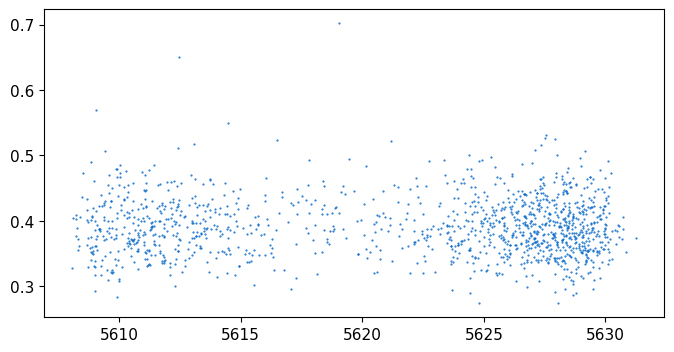

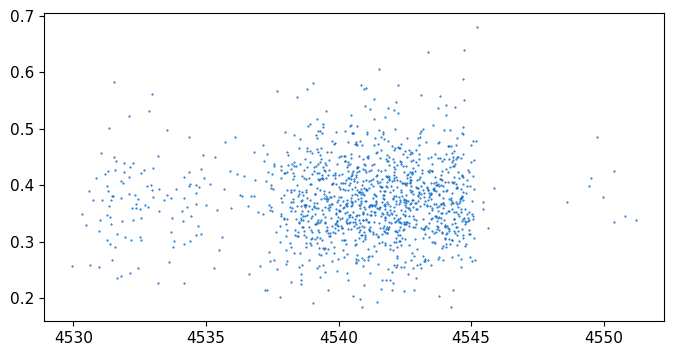

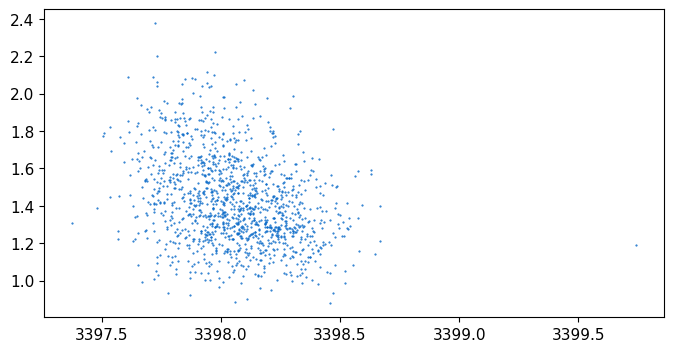

In [143]:
for t in tt:
    plt.figure()
    plt.plot(t['f_ge'], t['t1'], '.')
    plt.show()

## Random scan overlays

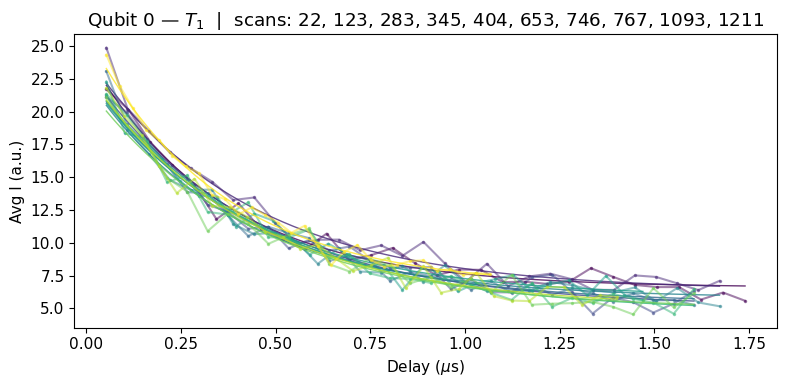

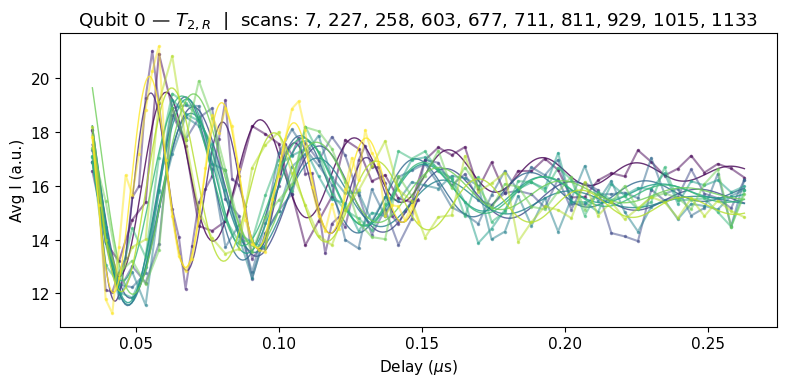

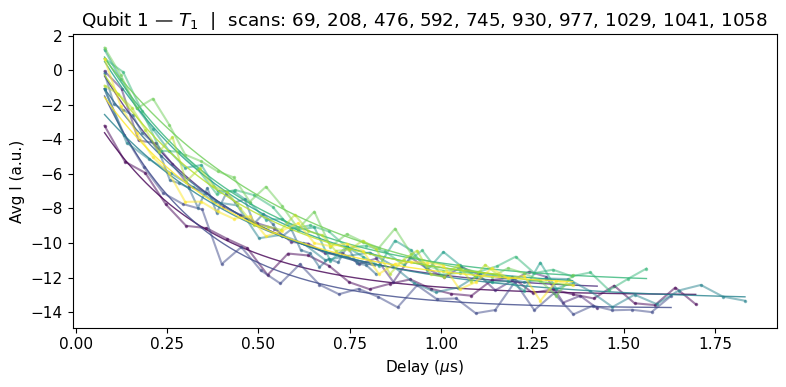

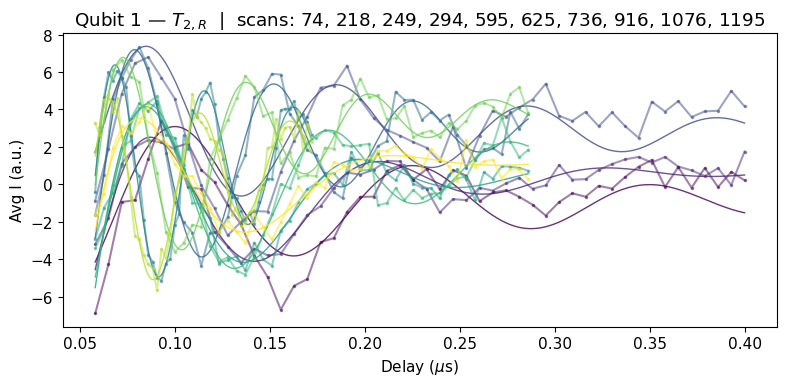

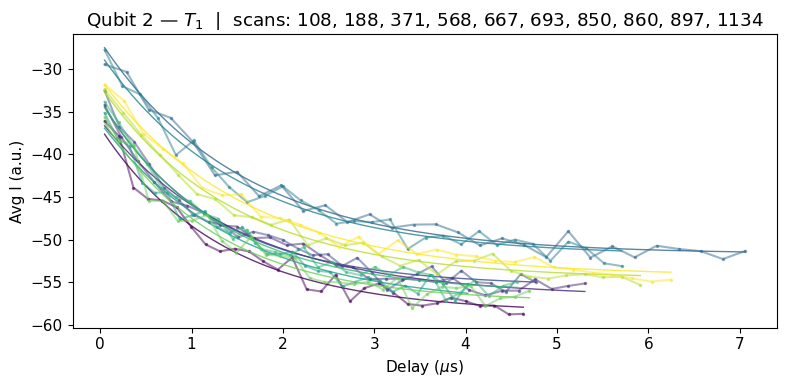

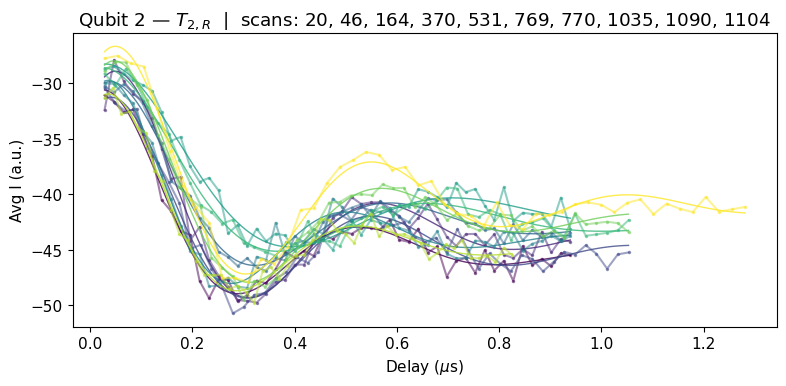

In [144]:
import h5py
from pathlib import Path
from slab_qick_calib.analysis.fitting import expfunc, decaysin, decayslopesin
from slab_qick_calib.analysis.collections import detect_t2_type

tracking_dir = Path(expt_path) / 'Tracking' / tracking_id
N_SCANS = 10

def load_scan(fpath):
    with h5py.File(fpath, 'r') as f:
        return {
            'xpts': f['xpts'][:],
            'avgi': f['avgi'][:],
            'fit': f['fit_avgi'][:],
        }

def t2_fit(x, fit):
    return decayslopesin(x, *fit) if len(fit) == 6 else decaysin(x, *fit)

qubits = [qi for qi, _ in enumerate(tt)]
colors = plt.cm.viridis(np.linspace(0, 1, N_SCANS))

T2_LABELS = {'T2e': '$T_{2,E}$', 'T2r': '$T_{2,R}$'}

for qi in qubits:
    # Auto-detect T2 type from HDF5 filenames
    t2_type = detect_t2_type(tracking_dir, qi)

    for expt_type, label, fit_fn in [
        (f't1_qubit{qi}', '$T_1$', lambda x, fit: expfunc(x, *fit)),
        (f'{t2_type}_qubit{qi}', T2_LABELS[t2_type], t2_fit),
    ]:
        files = sorted(tracking_dir.glob(f'{expt_type}_*'))
        if not files:
            print(f'No {label} files found for qubit {qi}')
            continue

        chosen = np.random.choice(len(files), size=min(N_SCANS, len(files)), replace=False)
        chosen_files = [files[i] for i in sorted(chosen)]

        fig, ax = plt.subplots()
        scan_labels = []
        for color, fpath in zip(colors, chosen_files):
            scan_num = int(fpath.stem.split('_')[-1])
            scan_labels.append(str(scan_num))
            d = load_scan(fpath)
            ax.plot(d['xpts'], d['avgi'], '.-', color=color, alpha=0.5, markersize=3)
            x_fit = np.linspace(d['xpts'][0], d['xpts'][-1], 300)
            ax.plot(x_fit, fit_fn(x_fit, d['fit']), '-', color=color, alpha=0.8, lw=1,
                    label=scan_num)

        ax.set_xlabel(r'Delay ($\mu$s)')
        ax.set_ylabel('Avg I (a.u.)')
        ax.set_title(f'Qubit {qi} — {label}  |  scans: {", ".join(scan_labels)}')
        plt.tight_layout()
        plt.show()


In [145]:
# import time
# while True:
#     tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)
#     tt, tt_ave = collections.process_data(tt)
#     tt = collections.add_losses(tt)
#     allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)
#     collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
#     plt.show()
#     time.sleep(600)

## Save stats to model config

In [146]:
qubit_params.stats(cfg_path, tt_stats, qubit_list)